In [1]:
# Import libraries
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Configure pandas display options
pd.set_option('display.max_columns', None)

# Extend graph width
plt.rcParams["figure.figsize"] = (20,10)

In [3]:
# Eternal Atake

# Load the dataset
eternal_atake = pd.read_csv("tweets/2024-10-12_17-17-59_tweets_1-26367.csv")

# Add a column to the dataset
eternal_atake["album"] = "Eternal Atake"

# Convert the Timestamp column to datetime
eternal_atake['date'] = pd.to_datetime(eternal_atake['Timestamp']).dt.date

# Sort the dataset by date
eternal_atake = eternal_atake.sort_values(by="date")

# Convert dates into indexes
eternal_atake["days"] = eternal_atake["date"].map(
    {
        date: i for i, date in enumerate(eternal_atake["date"].unique())
    }
)

In [4]:
# Combine the datasets
df = pd.concat([eternal_atake])

In [5]:
# Show first 5 rows
df.head()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,Mentions,Emojis,Profile Image,Tweet Link,Tweet ID,album,date,days
13183,dp,@dp1388,2020-03-06T20:31:49.000Z,False,can someone direct me to some actual good son...,1,0,0,0,[],[],[],https://pbs.twimg.com/profile_images/172901050...,https://x.com/dp1388/status/1236026723701055488,tweet_id:1236026723701055488,Eternal Atake,2020-03-06,0
17583,jord,@wokeuplikeuzi,2020-03-06T17:23:36.000Z,False,Welcome to eternal atake,0,0,3,0,[],[],[],https://pbs.twimg.com/profile_images/128460683...,https://x.com/wokeuplikeuzi/status/12359793568...,tweet_id:1235979356826038278,Eternal Atake,2020-03-06,0
17582,Preston,@Prestonc210,2020-03-06T17:23:37.000Z,False,Not one bad song. Eternal Atake hits fucking d...,0,0,0,0,[],['@LILUZIVERT'],[],https://pbs.twimg.com/profile_images/144225708...,https://x.com/Prestonc210/status/1235979359057...,tweet_id:1235979359057571841,Eternal Atake,2020-03-06,0
17581,weirdo,@asapweirdo,2020-03-06T17:23:38.000Z,False,Live (almost) Reaction to Eternal Atakeit took...,1,0,5,0,[],[],[],https://pbs.twimg.com/profile_images/173960932...,https://x.com/asapweirdo/status/12359793641452...,tweet_id:1235979364145205249,Eternal Atake,2020-03-06,0
17580,david,@david_wtv,2020-03-06T17:23:40.000Z,False,juro o sample da way back na prices do lil uzi...,0,0,1,0,[],[],[],https://pbs.twimg.com/profile_images/180790028...,https://x.com/david_wtv/status/123597937215209...,tweet_id:1235979372152094721,Eternal Atake,2020-03-06,0


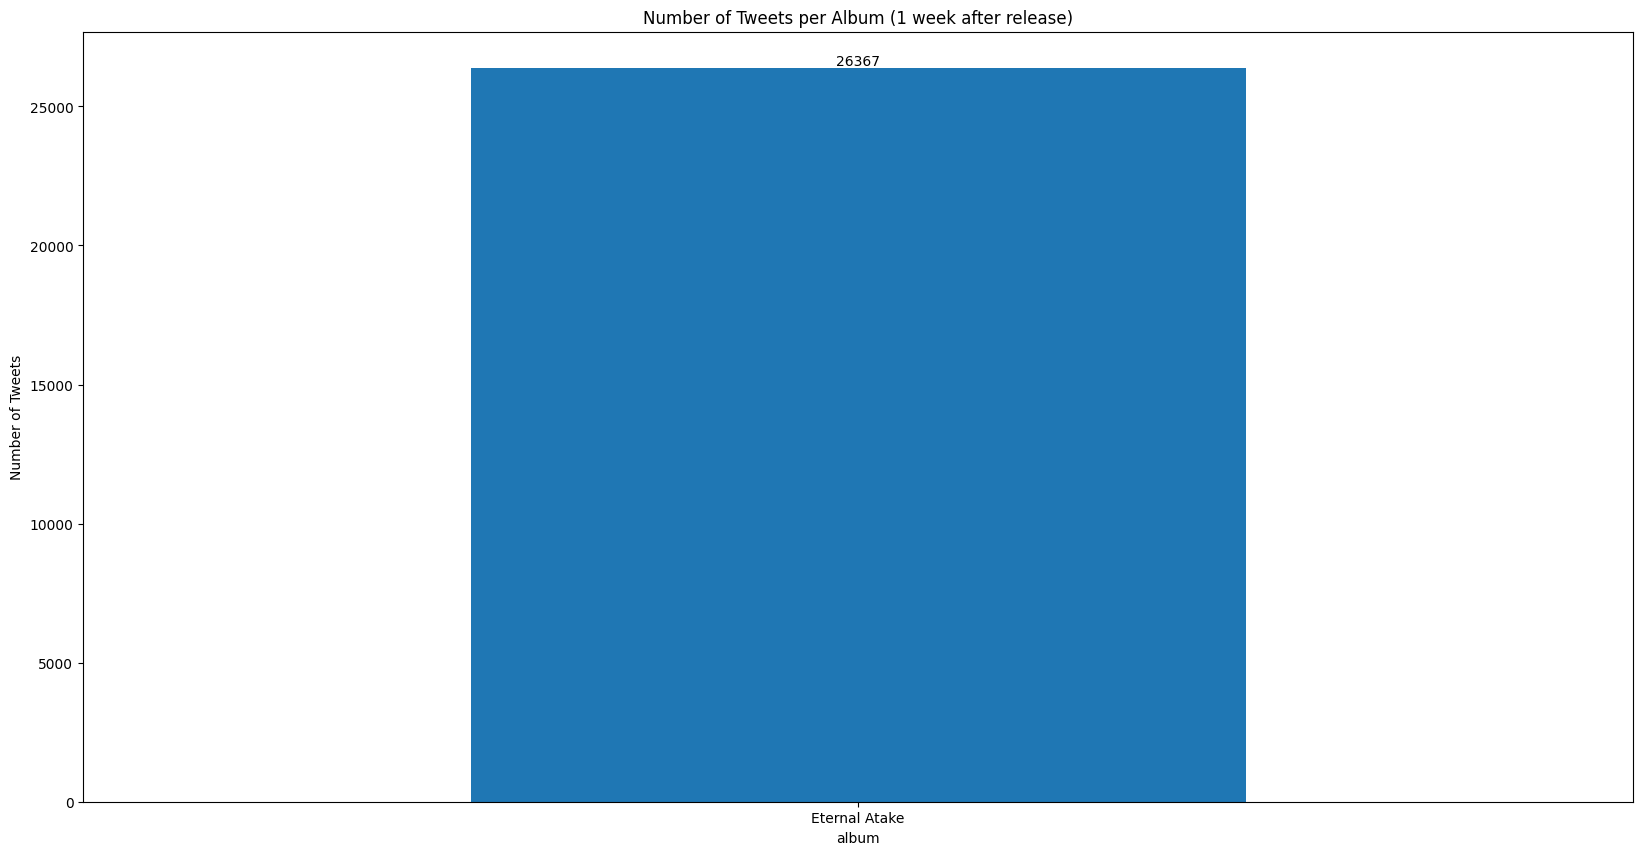

In [6]:
# Plot the number of tweets per album
tweet_counts = df.groupby(["album"])["Content"].count()
tweet_counts.plot(kind="bar")
plt.title("Number of Tweets per Album (1 week after release)")
plt.ylabel("Number of Tweets")

# Add the count on top of each bar
for i in range(len(tweet_counts)):
    plt.text(i, tweet_counts.iloc[i], tweet_counts.iloc[i], ha="center", va="bottom")

# Show the plot
plt.xticks(rotation=0)
plt.show()

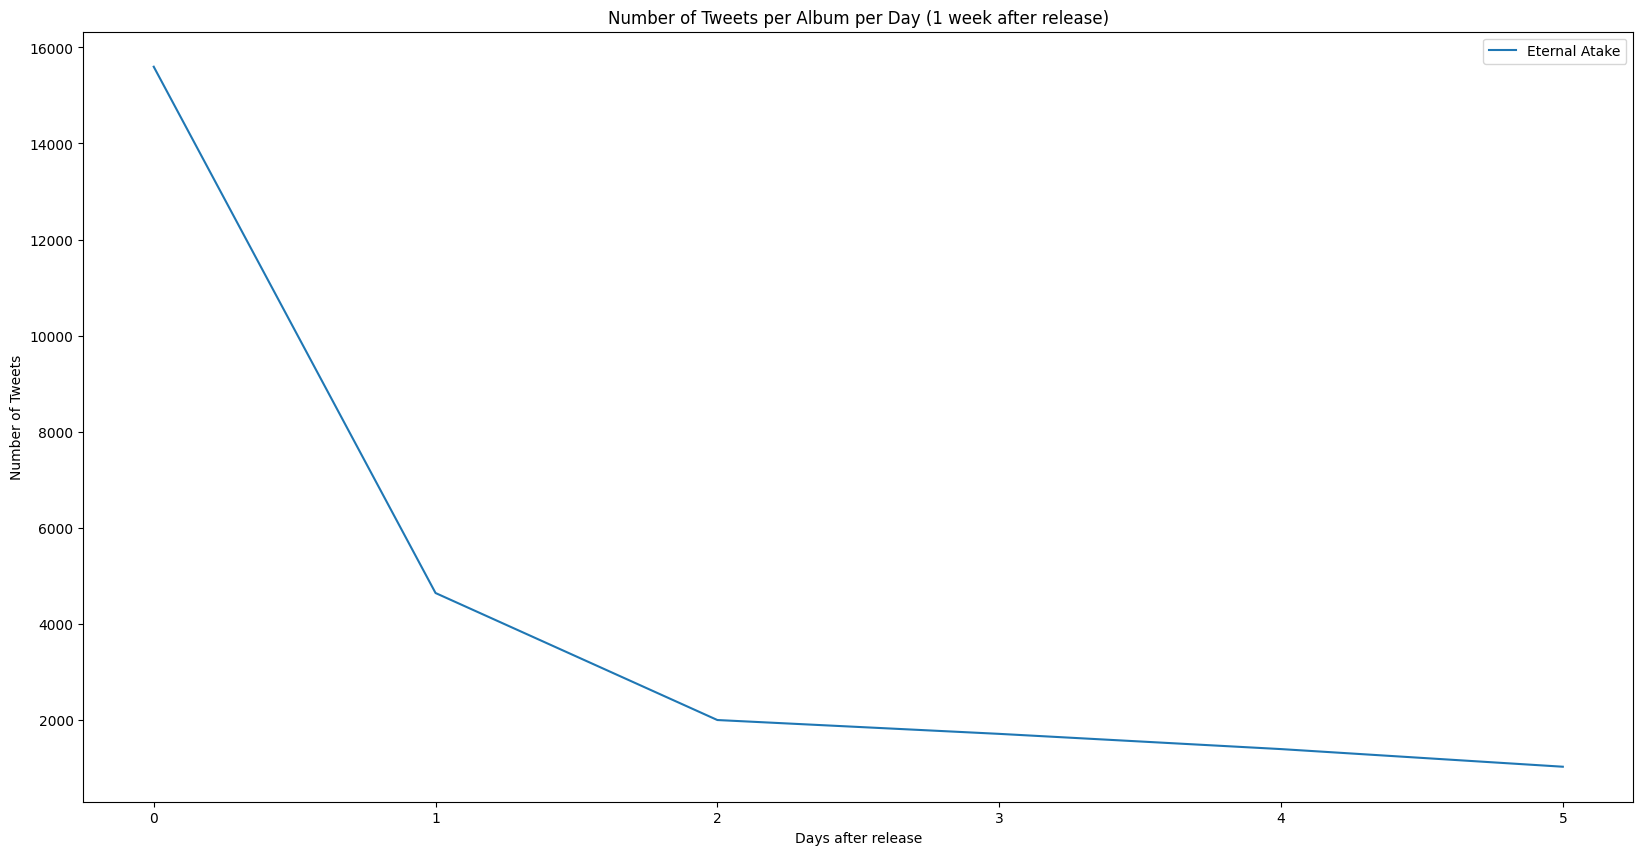

In [7]:
# Group the dataset by album and day
eternal_atake = df[df["album"] == "Eternal Atake"].groupby(["days"])["Content"].count()

# Plot the number of tweets per album per day in same line graph filter
eternal_atake.plot(kind="line", label="Eternal Atake")

# Show the plot
plt.title("Number of Tweets per Album per Day (1 week after release)")
plt.ylabel("Number of Tweets")
plt.xlabel("Days after release")
plt.legend()
plt.xticks(rotation=0)
plt.show()

In [8]:
# Load sentiment analysis library
from nltk.sentiment.vader import SentimentIntensityAnalyzer
from tqdm import tqdm

# Initialize the sentiment analyzer
sia = SentimentIntensityAnalyzer()

In [9]:
# Calculate sentiment scores
sentiments = []
for sentence in tqdm(df['Content']):
    sentiment = sia.polarity_scores(sentence)
    sentiments.append(sentiment)

# Add the sentiment scores to the dataframe
sentiments_df = pd.DataFrame(sentiments)
df = pd.concat([df, sentiments_df], axis=1)

100%|██████████| 26367/26367 [00:02<00:00, 12774.44it/s]


In [10]:
# Show the first 5 rows
df.head()

,Name,Handle,Timestamp,Verified,Content,Comments,Retweets,Likes,Analytics,Tags,Mentions,Emojis,Profile Image,Tweet Link,Tweet ID,album,date,days,neg,neu,pos,compound
13183,dp,@dp1388,2020-03-06T20:31:49.000Z,False,can someone direct me to some actual good son...,1,0,0,0,[],[],[],https://pbs.twimg.com/profile_images/172901050...,https://x.com/dp1388/status/1236026723701055488,tweet_id:1236026723701055488,Eternal Atake,2020-03-06,0,0.0,1.000,0.000,0.0000
17583,jord,@wokeuplikeuzi,2020-03-06T17:23:36.000Z,False,Welcome to eternal atake,0,0,3,0,[],[],[],https://pbs.twimg.com/profile_images/128460683...,https://x.com/wokeuplikeuzi/status/12359793568...,tweet_id:1235979356826038278,Eternal Atake,2020-03-06,0,0.0,1.000,0.000,0.0000
17582,Preston,@Prestonc210,2020-03-06T17:23:37.000Z,False,Not one bad song. Eternal Atake hits fucking d...,0,0,0,0,[],['@LILUZIVERT'],[],https://pbs.twimg.com/profile_images/144225708...,https://x.com/Prestonc210/status/1235979359057...,tweet_id:1235979359057571841,Eternal Atake,2020-03-06,0,0.0,1.000,0.000,0.0000
17581,weirdo,@asapweirdo,2020-03-06T17:23:38.000Z,False,Live (almost) Reaction to Eternal Atakeit took...,1,0,5,0,[],[],[],https://pbs.twimg.com/profile_images/173960932...,https://x.com/asapweirdo/status/12359793641452...,tweet_id:1235979364145205249,Eternal Atake,2020-03-06,0,0.0,0.889,0.111,0.3612
17580,david,@david_wtv,2020-03-06T17:23:40.000Z,False,juro o sample da way back na prices do lil uzi...,0,0,1,0,[],[],[],https://pbs.twimg.com/profile_images/180790028...,https://x.com/david_wtv/status/123597937215209...,tweet_id:1235979372152094721,Eternal Atake,2020-03-06,0,0.0,0.775,0.225,0.7783


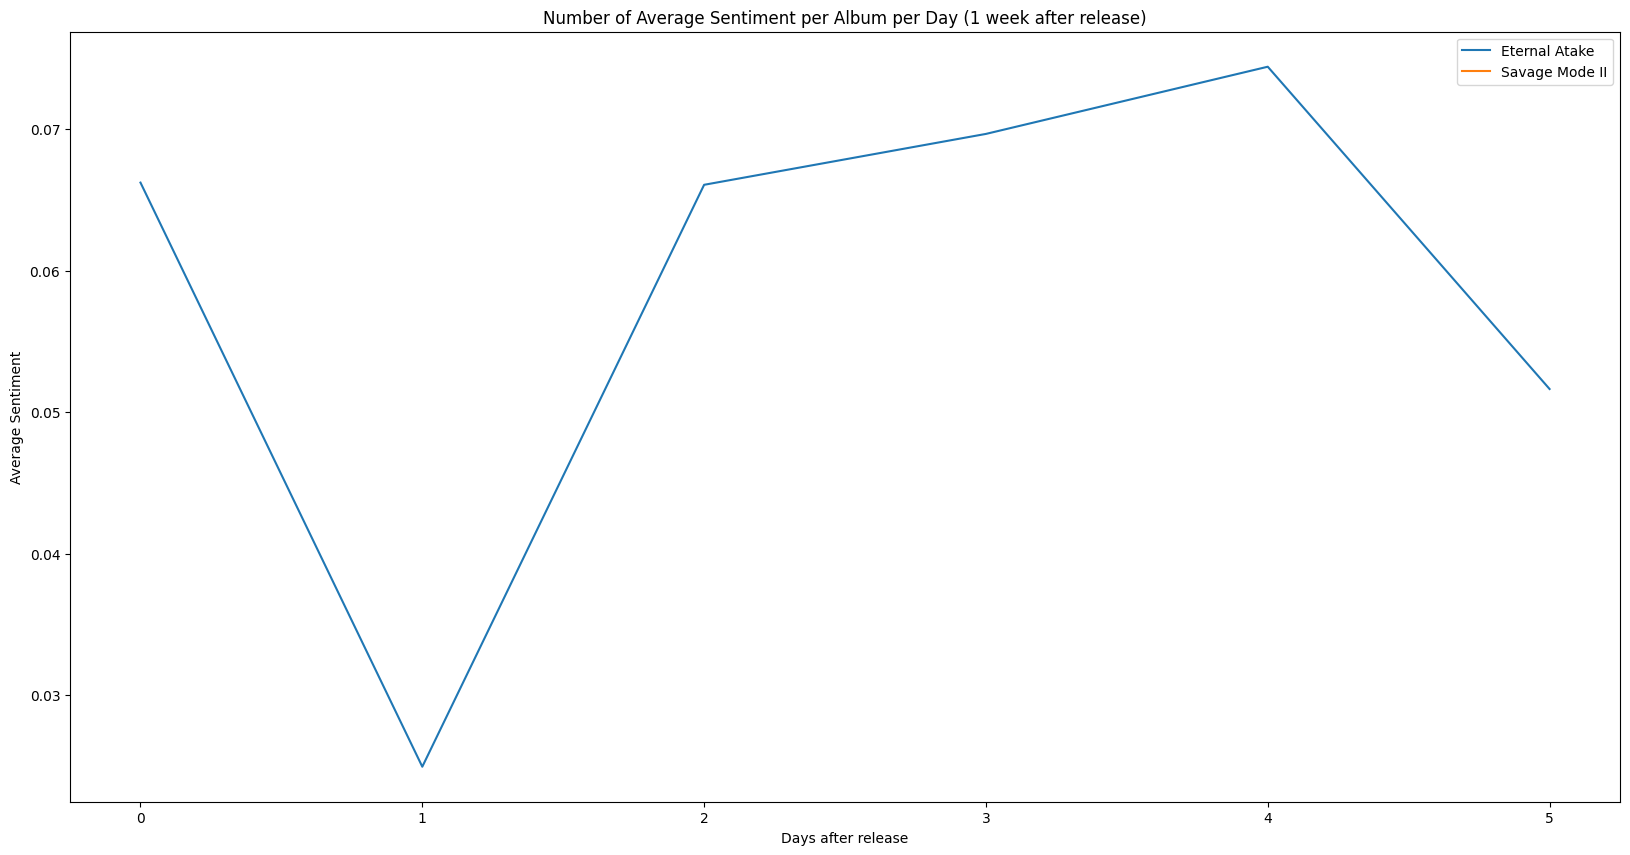

In [11]:
# Plot the sentiment scores per date
eternal_atake = df[df["album"] == "Eternal Atake"].groupby(["days"])["compound"].mean()
savage_mode = df[df["album"] == "Savage Mode II"].groupby(["days"])["compound"].mean()

# Plot the number of average sentiment per album per day
eternal_atake.plot(kind="line", label="Eternal Atake")
savage_mode.plot(kind="line", label="Savage Mode II")

# Show the plot
plt.title("Number of Average Sentiment per Album per Day (1 week after release)")
plt.ylabel("Average Sentiment")
plt.xlabel("Days after release")
plt.legend()
plt.xticks(rotation=0)
plt.show()